In [17]:
import sys
from pathlib import Path

# Go up one level from notebooks/ → project_root/
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [29]:
from src.preprocessing.meei_dataset import MEEIDataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torch

In [19]:
DATA_DIR = Path('../data/')
MAN_DIR = DATA_DIR / 'manifests'
RAW_DIR = DATA_DIR / 'raw'
XLSX_PATH = RAW_DIR / 'pat_info.xlsx'
PAR_PATH = MAN_DIR / 'image_manifest_images_only.parquet'

In [41]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [42]:
train_dataset = MEEIDataset(PAR_PATH, "train", eval_transform)
val_dataset = MEEIDataset(PAR_PATH, "val", eval_transform)
test_dataset = MEEIDataset(PAR_PATH, "test", eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

In [43]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['images', 'label', 'patient_id', 'pose_indices'])


In [44]:
print("Images shape:", batch["images"].shape)
print("Labels shape:", batch["label"].shape)

print("Patient IDs:", batch["patient_id"])
print("Pose indices:", batch["pose_indices"])
print("Labels:", batch["label"])

Images shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])
Patient IDs: ['ModerateSynkinetic3', 'CompleteFlaccid2', 'SevereFlaccid2', 'SevereFlaccid5']
Pose indices: [tensor([1., 1., 1., 1.], dtype=torch.float64), tensor([2., 2., 2., 2.], dtype=torch.float64), tensor([3., 3., 3., 3.], dtype=torch.float64), tensor([4., 4., 4., 4.], dtype=torch.float64), tensor([5., 5., 5., 5.], dtype=torch.float64), tensor([6., 6., 6., 6.], dtype=torch.float64), tensor([7., 7., 7., 7.], dtype=torch.float64), tensor([8., 8., 8., 8.], dtype=torch.float64)]
Labels: tensor([4, 6, 5, 5])


In [45]:
print("First patient ID:", batch["patient_id"][0])
print("First label:", batch["label"][0].item())
print("First patient image tensor shape:", batch["images"][0].shape)

First patient ID: ModerateSynkinetic3
First label: 4
First patient image tensor shape: torch.Size([8, 3, 224, 224])


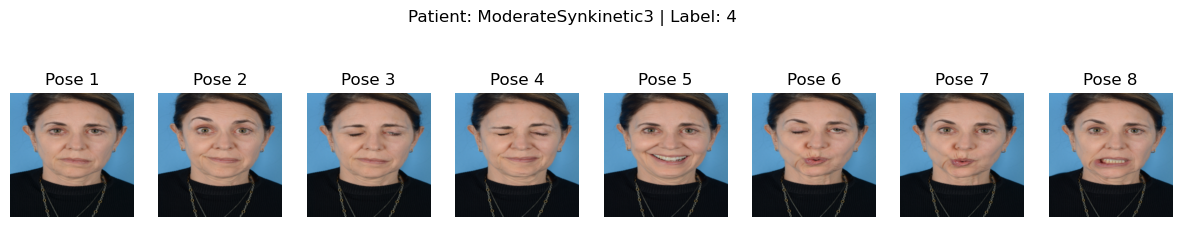

In [46]:
import matplotlib.pyplot as plt

def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0)
    return img.numpy()

first_images = batch["images"][0]
first_patient_id = batch["patient_id"][0]
first_label = batch["label"][0].item()

num_poses = first_images.shape[0]

plt.figure(figsize=(15, 3))
for i in range(num_poses):
    plt.subplot(1, num_poses, i + 1)
    plt.imshow(unnormalize(first_images[i]))
    plt.axis("off")
    plt.title(f"Pose {i+1}")

plt.suptitle(f"Patient: {first_patient_id} | Label: {first_label}")
plt.show()

In [31]:
for i, batch in enumerate(train_loader):
    print(f"Batch {i}")
    print("Images shape:", batch["images"].shape)
    print("Labels shape:", batch["label"].shape)
    print("First patient ID:", batch["patient_id"][0])
    print()

    if i == 2:
        break

Batch 0
Images shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])
First patient ID: SevereSynkinetic2

Batch 1
Images shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])
First patient ID: MildSynkinetic5

Batch 2
Images shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])
First patient ID: ModerateFlaccid4

